In [34]:
# importing necessary libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

import pandas as pd
import matplotlib.pyplot as plt

In [35]:
# creating a Spark session
spark = SparkSession.builder \
    .appName("Movie Database Analysis") \
    .getOrCreate()

print("Spark Started Successfully")

Spark Started Successfully


In [36]:
# loading the CSV file into a DataFrame
df = spark.read.csv(
    "movies.csv",
    header=True,
    inferSchema=True,
    multiLine=True,
    escape='"'
)

In [37]:
# displaying the first few rows of the DataFrame
df.show()

+------------+--------------------+--------------------+----------+----------+------------+-----------------+--------------------+--------------------+
|Release_Date|               Title|            Overview|Popularity|Vote_Count|Vote_Average|Original_Language|               Genre|          Poster_Url|
+------------+--------------------+--------------------+----------+----------+------------+-----------------+--------------------+--------------------+
|  2021-12-15|Spider-Man: No Wa...|Peter Parker is u...|  5083.954|      8940|         8.3|               en|Action, Adventure...|https://image.tmd...|
|  2022-03-01|          The Batman|In his second yea...|  3827.658|      1151|         8.1|               en|Crime, Mystery, T...|https://image.tmd...|
|  2022-02-25|             No Exit|Stranded at a res...|  2618.087|       122|         6.3|               en|            Thriller|https://image.tmd...|
|  2021-11-24|             Encanto|The tale of an ex...|  2402.201|      5076|         7

In [38]:

# Total records in the dataset
# Total number of rows
print("Rows:", df.count())

# Total number of columns
print("Columns:", len(df.columns))

# Display schema
df.printSchema()

Rows: 9827
Columns: 9
root
 |-- Release_Date: date (nullable = true)
 |-- Title: string (nullable = true)
 |-- Overview: string (nullable = true)
 |-- Popularity: double (nullable = true)
 |-- Vote_Count: integer (nullable = true)
 |-- Vote_Average: double (nullable = true)
 |-- Original_Language: string (nullable = true)
 |-- Genre: string (nullable = true)
 |-- Poster_Url: string (nullable = true)



In [39]:
# show column names
print(df.columns)

['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count', 'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url']


In [40]:
# 1.Count null values in each column
for c in df.columns:
    print(
        c,
        df.filter(
            col(c).isNull()
        ).count()
    )

Release_Date 0
Title 0
Overview 0
Popularity 0
Vote_Count 0
Vote_Average 0
Original_Language 0
Genre 0
Poster_Url 0


In [41]:
# 2. Data types of each column

print("\nData types of each column:")
for field in df.schema.fields:
    print(f"  {field.name}: {field.dataType}")


Data types of each column:
  Release_Date: DateType()
  Title: StringType()
  Overview: StringType()
  Popularity: DoubleType()
  Vote_Count: IntegerType()
  Vote_Average: DoubleType()
  Original_Language: StringType()
  Genre: StringType()
  Poster_Url: StringType()


In [42]:

# 3. TOP 10 MOST POPULAR MOVIES

movies_df = df.dropna()

movies_df.orderBy(
    desc("Popularity")
).select(
    "Title",
    "Popularity"
).show(10, truncate=False)

+-----------------------+----------+
|Title                  |Popularity|
+-----------------------+----------+
|Spider-Man: No Way Home|5083.954  |
|The Batman             |3827.658  |
|No Exit                |2618.087  |
|Encanto                |2402.201  |
|The King's Man         |1895.511  |
|The Commando           |1750.484  |
|Scream                 |1675.161  |
|Kimi                   |1601.782  |
|Fistful of Vengeance   |1594.013  |
|Eternals               |1537.406  |
+-----------------------+----------+
only showing top 10 rows


In [43]:

# 4. TOP RATED MOVIES

movies_df.orderBy(
    desc("Vote_Average")
).select(
    "Title",
    "Vote_Average"
).show(10, truncate=False)

+---------------------------------------------+------------+
|Title                                        |Vote_Average|
+---------------------------------------------+------------+
|Kung Fu Master Huo Yuanjia                   |10.0        |
|Franco Escamilla: Por La Anécdota            |9.2         |
|Demon Slayer: Kimetsu no Yaiba Sibling's Bond|9.1         |
|Impossible Things                            |9.1         |
|Mission «Sky»                                |9.0         |
|The Three Deaths of Marisela Escobedo        |9.0         |
|Sex School: Dorms of Desire                  |9.0         |
|My Sex Doll                                  |9.0         |
|Ni tuyo, Ni mía                              |8.9         |
|Bring the Soul: The Movie                    |8.9         |
+---------------------------------------------+------------+
only showing top 10 rows


In [44]:

# 5. Highly Rated Movies with Average Rating Greater than 8

movies_df.filter(
    col("Vote_Average") > 8
).select(
    "Title",
    "Vote_Average"
).show(20, truncate=False)

+------------------------------------------------------+------------+
|Title                                                 |Vote_Average|
+------------------------------------------------------+------------+
|Spider-Man: No Way Home                               |8.3         |
|The Batman                                            |8.1         |
|Sing 2                                                |8.2         |
|Demon Slayer -Kimetsu no Yaiba- The Movie: Mugen Train|8.4         |
|Turning Red                                           |8.6         |
|Ron's Gone Wrong                                      |8.1         |
|Cruella                                               |8.2         |
|Zack Snyder's Justice League                          |8.3         |
|Finch                                                 |8.1         |
|Avengers: Infinity War                                |8.3         |
|Miraculous World: New York, United HeroeZ             |8.3         |
|My Hero Academia: H

In [45]:
# 6.Most voted movies
df.orderBy(
    desc("Vote_Count")
).select(
    "Title",
    "Vote_Count"
).show(10, truncate=False)

+-----------------------+----------+
|Title                  |Vote_Count|
+-----------------------+----------+
|Inception              |31077     |
|Interstellar           |27975     |
|The Dark Knight        |26994     |
|The Avengers           |26490     |
|Deadpool               |26390     |
|Avatar                 |25011     |
|Avengers: Infinity War |24079     |
|Guardians of the Galaxy|24024     |
|Fight Club             |23620     |
|Pulp Fiction           |22733     |
+-----------------------+----------+
only showing top 10 rows


In [46]:
# 7. TOP LANGUAGES PRODUCING THE MOST MOVIES

language_df = movies_df.groupBy(
    "Original_Language"
).count() \
.orderBy(desc("count"))

language_df.show()

+-----------------+-----+
|Original_Language|count|
+-----------------+-----+
|               en| 7570|
|               ja|  645|
|               es|  339|
|               fr|  292|
|               ko|  170|
|               zh|  129|
|               it|  123|
|               cn|  109|
|               ru|   83|
|               de|   82|
|               pt|   37|
|               da|   28|
|               no|   26|
|               hi|   26|
|               sv|   23|
|               nl|   21|
|               pl|   17|
|               th|   17|
|               tr|   15|
|               id|   15|
+-----------------+-----+
only showing top 20 rows


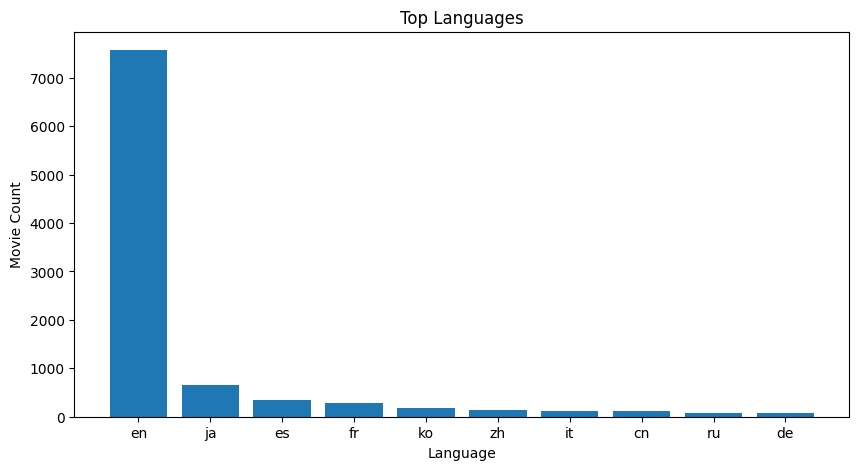

In [47]:
# 8.visualize the languages producing the most movies
language_pd = language_df.limit(10).toPandas()

plt.figure(figsize=(10,5))

plt.bar(
    language_pd["Original_Language"], 
    language_pd["count"]
)

plt.title("Top Languages")
plt.xlabel("Language")
plt.ylabel("Movie Count")

plt.show()


In [48]:
# 9. Average Rating By Languages


movies_df.groupBy("Original_Language") \
    .agg(
        round(avg("Vote_Average"), 2).alias("Average_Rating")
    ) \
    .orderBy(desc("Average_Rating")) \
    .show(10)

+-----------------+--------------+
|Original_Language|Average_Rating|
+-----------------+--------------+
|               ms|           7.7|
|               uk|          7.65|
|               fa|          7.57|
|               ar|          7.45|
|               hu|          7.33|
|               cs|           7.3|
|               ml|           7.2|
|               la|           7.1|
|               sv|          7.02|
|               et|           7.0|
+-----------------+--------------+
only showing top 10 rows


In [49]:
# 10. TOP GENRES PRODUCING THE MOST MOVIES
genre_df = movies_df.groupBy(
    "Genre"
).count() \
.orderBy(desc("count"))

genre_df.show(15, truncate=False)

+----------------------+-----+
|Genre                 |count|
+----------------------+-----+
|Drama                 |466  |
|Comedy                |403  |
|Drama, Romance        |248  |
|Horror                |238  |
|Horror, Thriller      |199  |
|Comedy, Romance       |196  |
|Documentary           |139  |
|Comedy, Drama         |137  |
|Action, Thriller      |125  |
|Comedy, Drama, Romance|107  |
|Thriller              |105  |
|Action                |99   |
|Drama, History        |94   |
|Drama, Thriller       |94   |
|Romance, Drama        |87   |
+----------------------+-----+
only showing top 15 rows


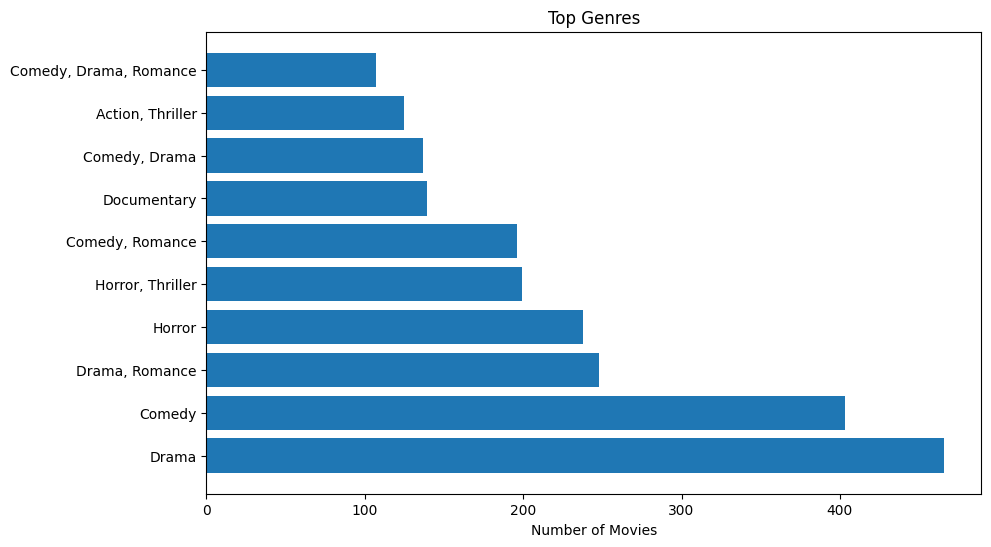

In [50]:
# 11. Visualize the genres producing the most movies
genre_pd = genre_df.limit(10).toPandas()

plt.figure(figsize=(10,6))

plt.barh(
    genre_pd["Genre"],
    genre_pd["count"]
)

plt.title("Top Genres")
plt.xlabel("Number of Movies")

plt.show()

In [51]:
# 12. Count of number of Movies Released Year-Wise

year_df = df.withColumn(
    "Year",
    year("Release_Date")
).groupBy(
    "Year"
).count().orderBy("Year")

year_df.show()

+----+-----+
|Year|count|
+----+-----+
|1902|    1|
|1920|    1|
|1921|    2|
|1922|    2|
|1925|    1|
|1926|    2|
|1927|    2|
|1929|    1|
|1930|    1|
|1931|    5|
|1932|    5|
|1933|    4|
|1935|    3|
|1936|    2|
|1937|    2|
|1938|    5|
|1939|    6|
|1940|    6|
|1941|    6|
|1942|    4|
+----+-----+
only showing top 20 rows


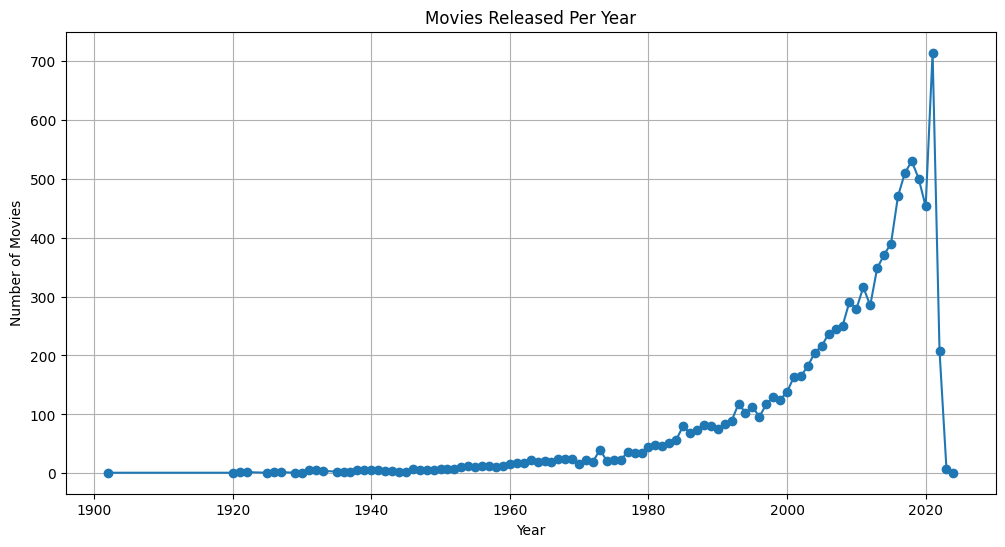

In [52]:
# 13. Visualize the number of movies released year-wise

year_pd = year_df.toPandas()

plt.figure(figsize=(12,6))

plt.plot(
    year_pd["Year"],
    year_pd["count"],
    marker="o"
)

plt.title("Movies Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.grid(True)

plt.show()

In [53]:
# 14. Popularity Distribution
movies_df.withColumn(
    "Popularity_Level",
    when(col("Popularity") < 500, "Low")
    .when(col("Popularity") < 1500, "Medium")
    .otherwise("High")
).groupBy(
    "Popularity_Level"
).count().show()

+----------------+-----+
|Popularity_Level|count|
+----------------+-----+
|            High|   11|
|             Low| 9778|
|          Medium|   38|
+----------------+-----+



In [54]:
# 15. Top Rated Movies with more than 1000 votes
movies_df.filter(
    col("Vote_Count") > 1000
).orderBy(
    desc("Vote_Average")
).select(
    "Title",
    "Vote_Average",
    "Vote_Count"
).show(20, truncate=False)

+---------------------------------------------+------------+----------+
|Title                                        |Vote_Average|Vote_Count|
+---------------------------------------------+------------+----------+
|The Shawshank Redemption                     |8.7         |20911     |
|The Godfather                                |8.7         |15614     |
|Dilwale Dulhania Le Jayenge                  |8.7         |3474      |
|The Godfather: Part II                       |8.6         |9393      |
|Schindler's List                             |8.6         |12474     |
|The Dark Knight                              |8.5         |26994     |
|Your Name.                                   |8.5         |8426      |
|The Lord of the Rings: The Return of the King|8.5         |19183     |
|Parasite                                     |8.5         |13240     |
|Spirited Away                                |8.5         |12531     |
|The Green Mile                               |8.5         |1360

In [55]:
# 16. Top Rated Movies with more than 1000 votes and popularity greater than 500
movies_df.filter(
    col("Vote_Count") > 1000
).orderBy(
    desc("Vote_Average")
).select(
    "Title",
    "Vote_Average",
    "Vote_Count"
).show(20, truncate=False)

+---------------------------------------------+------------+----------+
|Title                                        |Vote_Average|Vote_Count|
+---------------------------------------------+------------+----------+
|The Shawshank Redemption                     |8.7         |20911     |
|The Godfather                                |8.7         |15614     |
|Dilwale Dulhania Le Jayenge                  |8.7         |3474      |
|The Godfather: Part II                       |8.6         |9393      |
|Schindler's List                             |8.6         |12474     |
|The Dark Knight                              |8.5         |26994     |
|Your Name.                                   |8.5         |8426      |
|The Lord of the Rings: The Return of the King|8.5         |19183     |
|Parasite                                     |8.5         |13240     |
|Spirited Away                                |8.5         |12531     |
|The Green Mile                               |8.5         |1360

In [56]:
# 17. Correlation between Popularity and Vote Average
movies_df.select(
    corr(
        "Popularity",
        "Vote_Average"
    )
).show()

+------------------------------+
|corr(Popularity, Vote_Average)|
+------------------------------+
|           0.05384399077595603|
+------------------------------+



In [57]:
# 18.Movies Released After year 2000

from pyspark.sql.functions import year, col

movies_after_2000 = movies_df.filter(
    year(col("Release_Date")) > 2000
)

print("Total Movies Released After 2000:", movies_after_2000.count())

Total Movies Released After 2000: 7338


In [58]:

# 19.Summary Statistics
movies_df.select(
    "Popularity",
    "Vote_Count",
    "Vote_Average"
).describe().show()

+-------+------------------+------------------+------------------+
|summary|        Popularity|        Vote_Count|      Vote_Average|
+-------+------------------+------------------+------------------+
|  count|              9827|              9827|              9827|
|   mean|40.326088226315264|1392.8055357688002| 6.439533937112049|
| stddev|  108.873998048583|2611.2069068183096|1.1297591316946558|
|    min|            13.354|                 0|               0.0|
|    max|          5083.954|             31077|              10.0|
+-------+------------------+------------------+------------------+



In [59]:
# stopping the Spark session
spark.stop()